PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [1]:
# Instala dependencias
!pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

In [2]:
pip install --upgrade pandas pyarrow --force-reinstall


  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (12.4 MB)
Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl (47.7 MB)
Using cached numpy-2.3.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.p

1.- DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha.

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [3]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [4]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/train.parquet");
napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'numerai-datasets-us-west-2.s3-us-west-2.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
v5.0/train.parquet: 2.37GB [00:51, 46.4MB/s]                            
v5.0/features.json: 291kB [00:00, 1.97MB/s]                          


small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


###Visualización de cuántas filas hay en cada era




> La gráfica de eras muestra cuántas acciones (filas) hay en cada semana del dataset, y es importante porque permite entender la estructura temporal de las acciones. En el contexto financiero, de las acciones, sirve para verificar si el número de acciones disponibles cada semana es consistente, detectar cambios en el mercado y evitar sesgos temporales al entrenar el modelo.




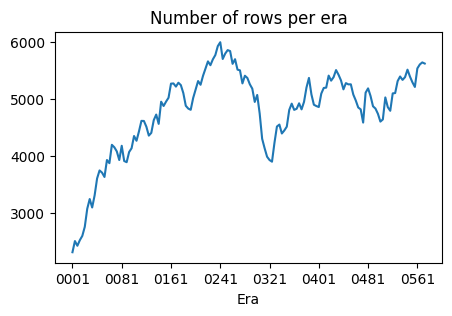

In [5]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

###Detectar tendencias, volatilidad temporal



> La gráfica del target por era es importante porque muestra cómo varían los rendimientos específicos de las acciones y su volatilidad a lo largo del tiempo. Permite identificar semanas con mejores o peores resultados promedio, detectar cambios en el comportamiento del mercado o inestabilidades en los datos, y evaluar si el entorno en el que se entrenará el modelo es estable y consistente. En resumen, ayuda a entender la evolución temporal del rendimiento del mercado y la calidad del dataset financiero.




In [6]:
import matplotlib.pyplot as plt

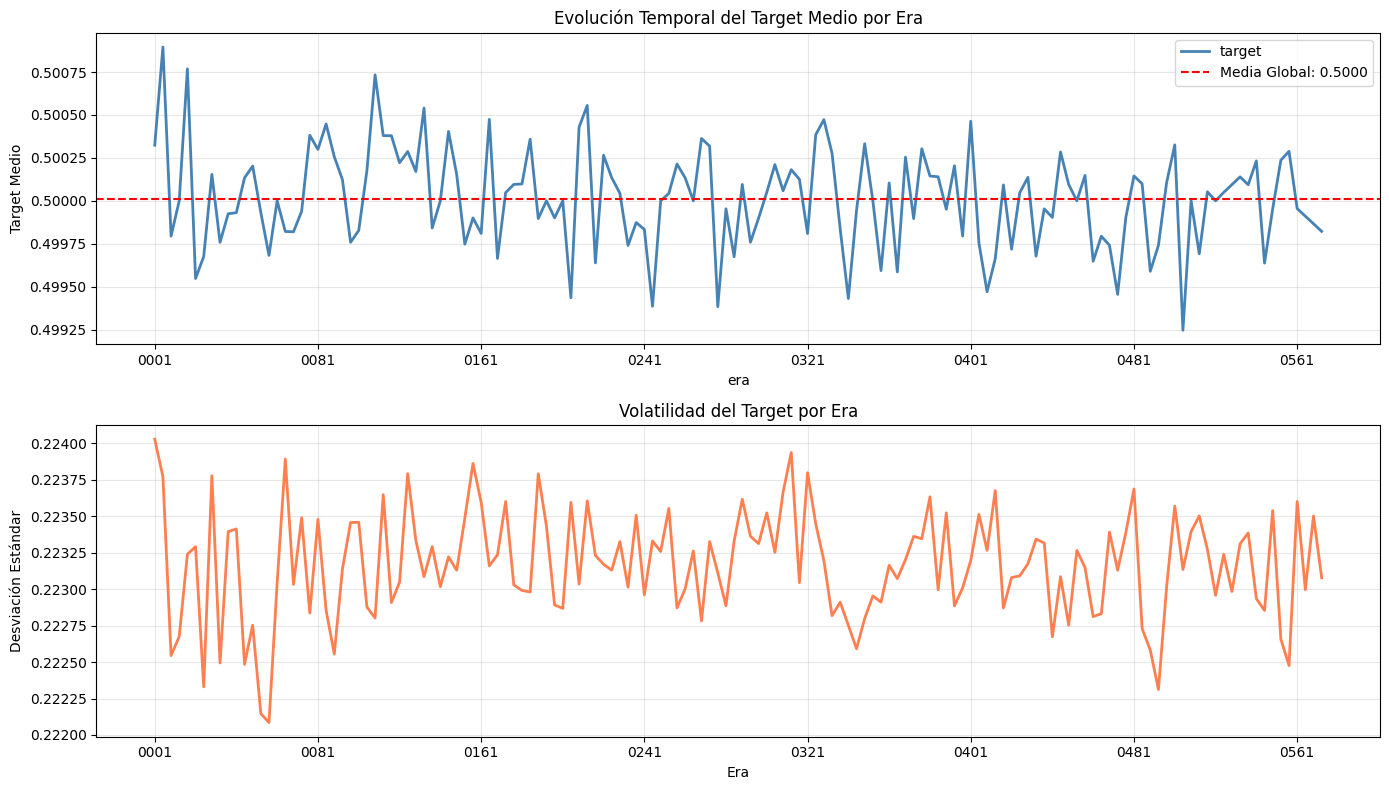

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

target_by_era = train.groupby('era')['target'].mean()
target_std_by_era = train.groupby('era')['target'].std()

# Media del target por era
target_by_era.plot(ax=ax1, linewidth=2, color='steelblue')
ax1.axhline(train['target'].mean(), color='red', linestyle='--',
            label=f'Media Global: {train["target"].mean():.4f}')
ax1.set_ylabel('Target Medio')
ax1.set_title('Evolución Temporal del Target Medio por Era')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volatilidad (std) por era
target_std_by_era.plot(ax=ax2, linewidth=2, color='coral')
ax2.set_ylabel('Desviación Estándar')
ax2.set_xlabel('Era')
ax2.set_title('Volatilidad del Target por Era')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

###Distribución de Features

In [8]:
# Número de características
len(feature_set)

42



> La gráfica de distribución de features es importante porque permite observar cómo se comportan las variables que usa el modelo para predecir el rendimiento de las acciones. Ayuda a detectar desequilibrios, valores atípicos o patrones extraños en los datos, asegurando que las características estén bien distribuidas y sean informativas y confiables para el entrenamiento del modelo financiero.




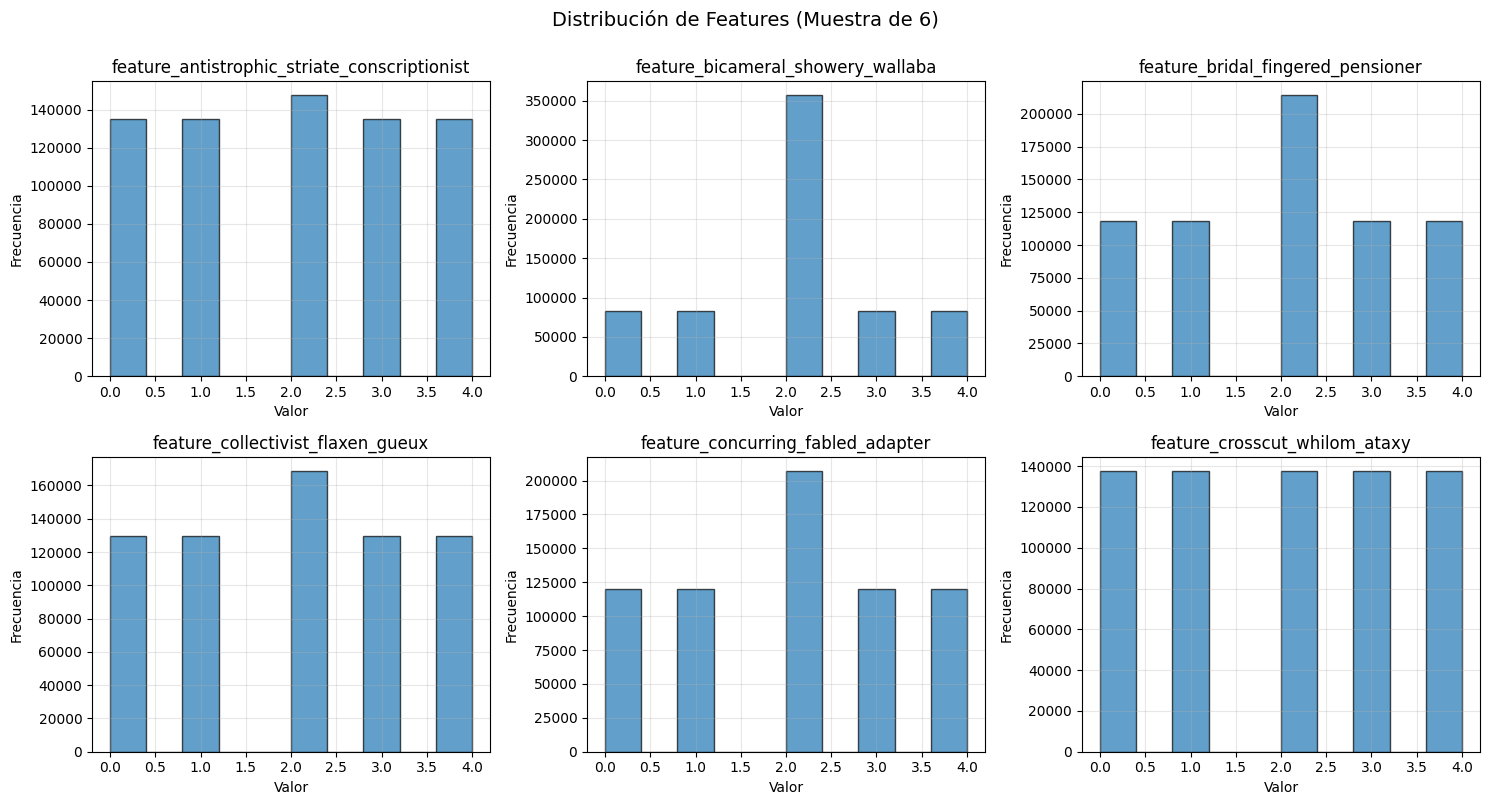

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

sample_features = feature_set[:6]
for i, feat in enumerate(sample_features):
    train[feat].hist(bins=10, ax=axes[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{feat}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribución de Features (Muestra de 6)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('grafica4_distribucion_features.png', bbox_inches='tight')
plt.show()

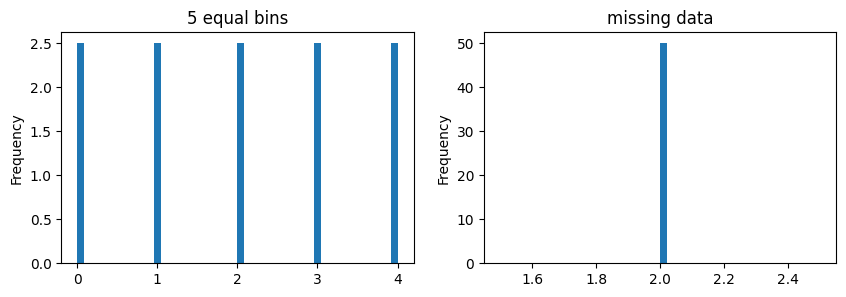

In [10]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);



> Mostrar el histograma de densidad del target es importante porque permite visualizar la distribución de los rendimientos específicos de las acciones y entender cómo se comportan los valores estandarizados en los distintos rangos (0, 0.25, 0.5, 0.75, 1.0). Esta gráfica ayuda a detectar si los datos están equilibrados o si existen sesgos o concentraciones excesivas en ciertos intervalos, lo cual es clave para evaluar la calidad del objetivo antes de entrenar un modelo.




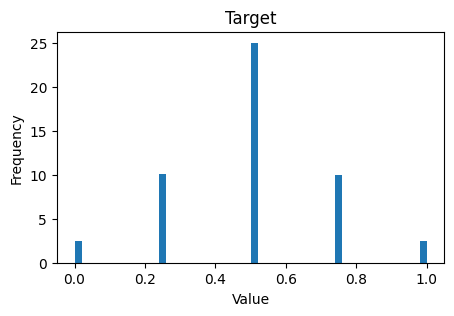

In [11]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

###Visualicación de correlacion con Target



> Mostrar esta gráfica es importante porque permite identificar qué variables tienen mayor relación con el target, es decir, cuáles características del conjunto de datos están más asociadas con los rendimientos específicos de las acciones. Al calcular y visualizar las correlaciones absolutas, se puede detectar rápidamente qué features podrían ser más útiles para el modelo predictivo y cuáles tienen poca relevancia. Además, esta visualización ayuda a priorizar variables durante la selección de características y a reducir dimensionalidad, evitando incluir información redundante o poco informativa.






📊 Correlaciones con Target:
feature_snakiest_somalian_wavelet              0.010715
feature_trimeter_soggy_greatest                0.009701
feature_willful_sere_chronobiology             0.009490
feature_jewish_stained_disembowelment          0.009227
feature_stretchy_spiniest_fizgig               0.007674
feature_pottier_unmanly_collyrium              0.007612
feature_departmental_inimitable_sentencer      0.007156
feature_transisthmian_yogic_linden             0.006980
feature_musicianly_aspirate_creativity         0.006951
feature_simulated_nonclassified_intercessor    0.006767
dtype: float64


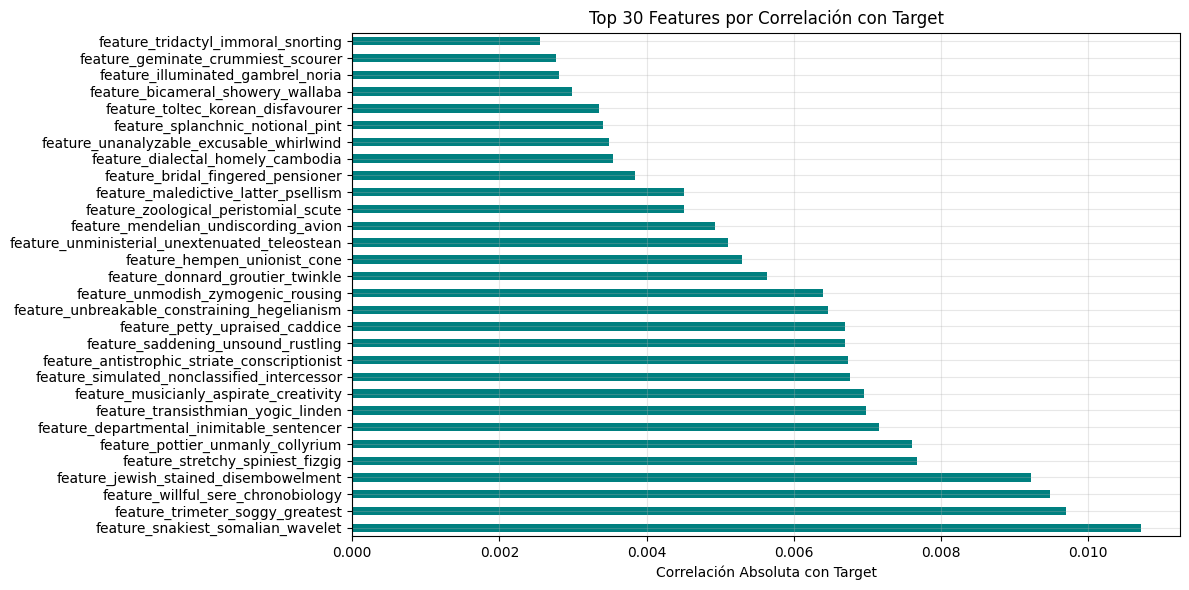

In [12]:
correlations = train[feature_set].corrwith(train['target']).abs().sort_values(ascending=False)

print(f"\n📊 Correlaciones con Target:")
print(correlations.head(10))

# Visualización de correlaciones
fig, ax = plt.subplots(figsize=(12, 6))
correlations.head(30).plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Correlación Absoluta con Target')
ax.set_title('Top 30 Features por Correlación con Target')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica5_correlaciones_features.png', bbox_inches='tight')
plt.show()

###Matriz de correlación entre las features

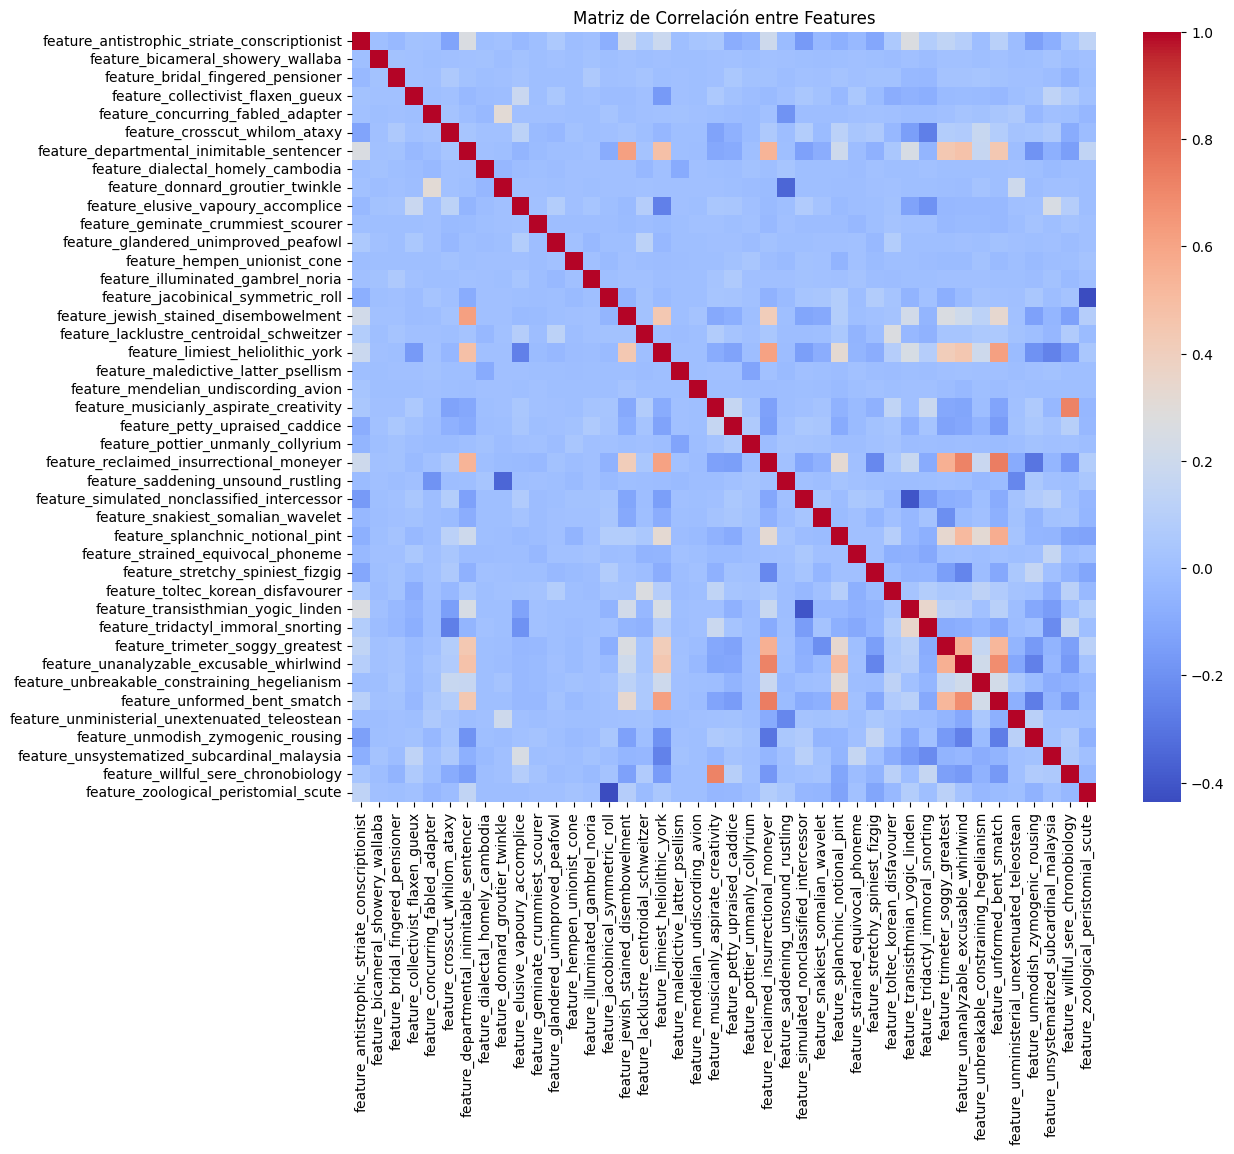

In [13]:
import seaborn as sns
# Calcula la matriz de correlación entre las features
correlation_matrix = train[feature_set].corr()

# Crea un mapa de calor para visualizar la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Matriz de Correlación entre Features')
plt.show()

###Eliminando características poco relevantes



> Para mejorar la precisión del modelo, aplico un proceso de selección de características basado en la correlación con el target. Calculando la correlación absoluta entre cada variable y el target, estableciendo un umbral mínimo de `threshold_corr = 0.001` para conservar aquellas variables que mantienen una relación, aunque sea débil, pero potencialmente informativa con el rendimiento de las acciones. Este enfoque permite reducir el ruido eliminando características irrelevantes, sin descartar señales sutiles que puedan aportar valor predictivo, logrando así un equilibrio entre simplicidad del modelo y capacidad de generalización.




In [14]:
# Obtener solo las columnas que son features en el DataFrame actual (excluyendo 'era' y 'target')
current_features = [col for col in train.columns if col not in ['era', 'target']]

# Recalcular las correlaciones con el target usando solo las features actuales
correlations = train[current_features].corrwith(train['target']).abs().sort_values(ascending=False)

threshold_corr = 0.001
selected_features_corr = correlations[correlations > threshold_corr].index.tolist()

# filtrar el DataFrame train con las características seleccionadas y 'target'
cols_to_keep = selected_features_corr + ['target']
if 'era' in train.columns:
    cols_to_keep.insert(0, 'era')

train = train[cols_to_keep]

print(f"Número de características seleccionadas después de filtrar por correlación ({threshold_corr}): {len(selected_features_corr)}")
print("Columnas restantes en el DataFrame 'train':")
print(train.columns.tolist())

Número de características seleccionadas después de filtrar por correlación (0.001): 38
Columnas restantes en el DataFrame 'train':
['era', 'feature_snakiest_somalian_wavelet', 'feature_trimeter_soggy_greatest', 'feature_willful_sere_chronobiology', 'feature_jewish_stained_disembowelment', 'feature_stretchy_spiniest_fizgig', 'feature_pottier_unmanly_collyrium', 'feature_departmental_inimitable_sentencer', 'feature_transisthmian_yogic_linden', 'feature_musicianly_aspirate_creativity', 'feature_simulated_nonclassified_intercessor', 'feature_antistrophic_striate_conscriptionist', 'feature_saddening_unsound_rustling', 'feature_petty_upraised_caddice', 'feature_unbreakable_constraining_hegelianism', 'feature_unmodish_zymogenic_rousing', 'feature_donnard_groutier_twinkle', 'feature_hempen_unionist_cone', 'feature_unministerial_unextenuated_teleostean', 'feature_mendelian_undiscording_avion', 'feature_zoological_peristomial_scute', 'feature_maledictive_latter_psellism', 'feature_bridal_fingere

In [15]:
print(len(selected_features_corr))
print(selected_features_corr)


38
['feature_snakiest_somalian_wavelet', 'feature_trimeter_soggy_greatest', 'feature_willful_sere_chronobiology', 'feature_jewish_stained_disembowelment', 'feature_stretchy_spiniest_fizgig', 'feature_pottier_unmanly_collyrium', 'feature_departmental_inimitable_sentencer', 'feature_transisthmian_yogic_linden', 'feature_musicianly_aspirate_creativity', 'feature_simulated_nonclassified_intercessor', 'feature_antistrophic_striate_conscriptionist', 'feature_saddening_unsound_rustling', 'feature_petty_upraised_caddice', 'feature_unbreakable_constraining_hegelianism', 'feature_unmodish_zymogenic_rousing', 'feature_donnard_groutier_twinkle', 'feature_hempen_unionist_cone', 'feature_unministerial_unextenuated_teleostean', 'feature_mendelian_undiscording_avion', 'feature_zoological_peristomial_scute', 'feature_maledictive_latter_psellism', 'feature_bridal_fingered_pensioner', 'feature_dialectal_homely_cambodia', 'feature_unanalyzable_excusable_whirlwind', 'feature_splanchnic_notional_pint', 'fea

Ver cuantos nulos hay

In [16]:
train.isnull().sum()

,0
era,0
feature_snakiest_somalian_wavelet,0
feature_trimeter_soggy_greatest,0
feature_willful_sere_chronobiology,0
feature_jewish_stained_disembowelment,0
feature_stretchy_spiniest_fizgig,0
feature_pottier_unmanly_collyrium,0
feature_departmental_inimitable_sentencer,0
feature_transisthmian_yogic_linden,0
feature_musicianly_aspirate_creativity,0


###Reducir dimensionalidad con PCA



> El gráfico muestra que los primeros componentes principales del PCA concentran la mayor parte de la información de las features. En concreto, unas 15 a 20 componentes son suficientes para conservar cerca del 80% de la varianza total, lo que indica alta correlación entre variables y el conjunto de datos puede reducirse eficientemente sin perder capacidad explicativa.

Por otra parte, he usado un proceso de preprocesamiento que incluyó la estandarización de las variables antes de realizar el PCA. Esto fue necesario porque las features representan distintos tipos de medidas financieras y técnicas con escalas muy diferentes. Al estandarizar, todas las variables quedan en una misma escala, evitando que aquellas con valores más grandes dominen el análisis. Además, este paso mejora la efectividad del PCA, ya que este método se basa en la varianza de las variables y requiere que todas contribuyan de forma equilibrada al cálculo de los componentes principales.




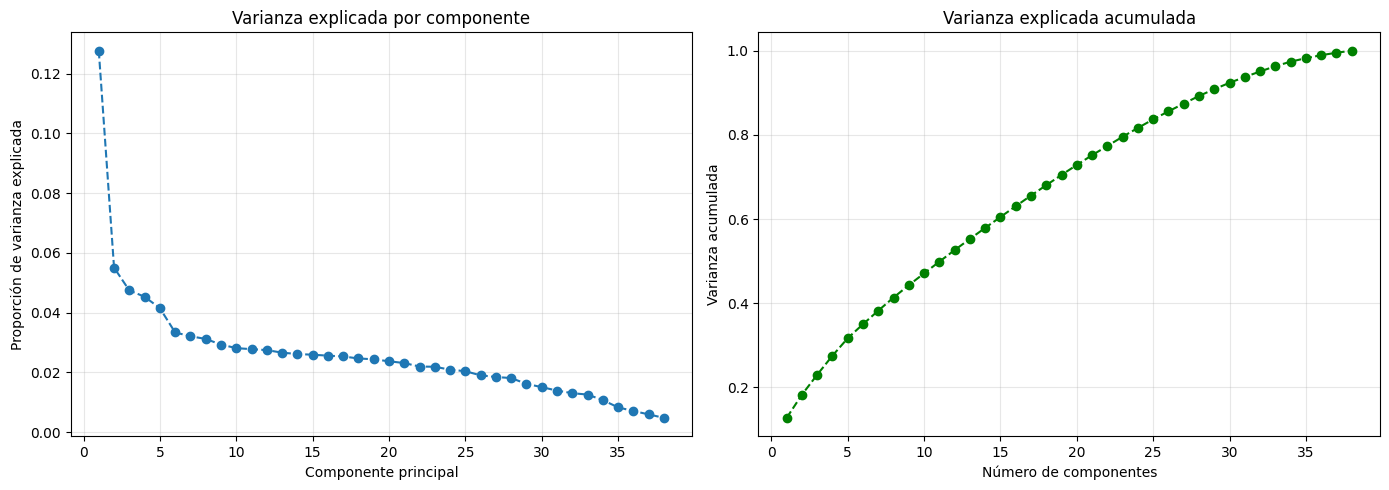

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Definir X_for_pca con las columnas de características del DataFrame train
# Excluir 'era' y 'target'
feature_cols_pca = [col for col in train.columns if col not in ['era', 'target']]
X_for_pca = train[feature_cols_pca]

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_pca)

# Aplicar PCA
pca = PCA(n_components=None)
pca.fit(X_scaled)

# Transformar los datos
X_pca = pca.transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
train_pca = pd.DataFrame(X_pca, index=train.index, columns=pca_cols)

# Añadir la columna 'target' y 'era' al DataFrame de PCA
if 'target' in train.columns:
    train_pca['target'] = train['target']
if 'era' in train.columns:
    train_pca['era'] = train['era']


#  Calcular la varianza explicada acumulada
variance_explained = np.cumsum(pca.explained_variance_ratio_)

# Graficar la varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por cada componente
ax1.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o', linestyle='--')
ax1.set_title('Varianza explicada por componente')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Proporción de varianza explicada')
ax1.grid(True, alpha=0.3)

# Varianza explicada acumulada
ax2.plot(range(1, len(variance_explained) + 1), variance_explained, marker='o', color='green', linestyle='--')
ax2.set_title('Varianza explicada acumulada')
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

###Comparar correlación antes y después de PCA



> En este caso, aplicar PCA sí representa una mejora respecto a entrenar el modelo con todas las features originales. La gráfica muestra que los componentes principales presentan correlaciones más consistentes y ligeramente más altas con el target, lo que indica que el PCA logró concentrar la información relevante en menos variables, eliminando ruido y redundancia. Esto permite simplificar el modelo, reducir el riesgo de sobreajuste y mantener o incluso mejorar la capacidad predictiva al usar un conjunto de datos más compacto y representativo.





 TOP 10 COMPONENTES PRINCIPALES MÁS CORRELACIONADOS:
PC11    0.013080
PC33    0.011936
PC19    0.011774
PC3     0.010517
PC32    0.010242
PC25    0.008492
PC24    0.008460
PC6     0.008262
PC10    0.007050
PC23    0.005484
dtype: float64


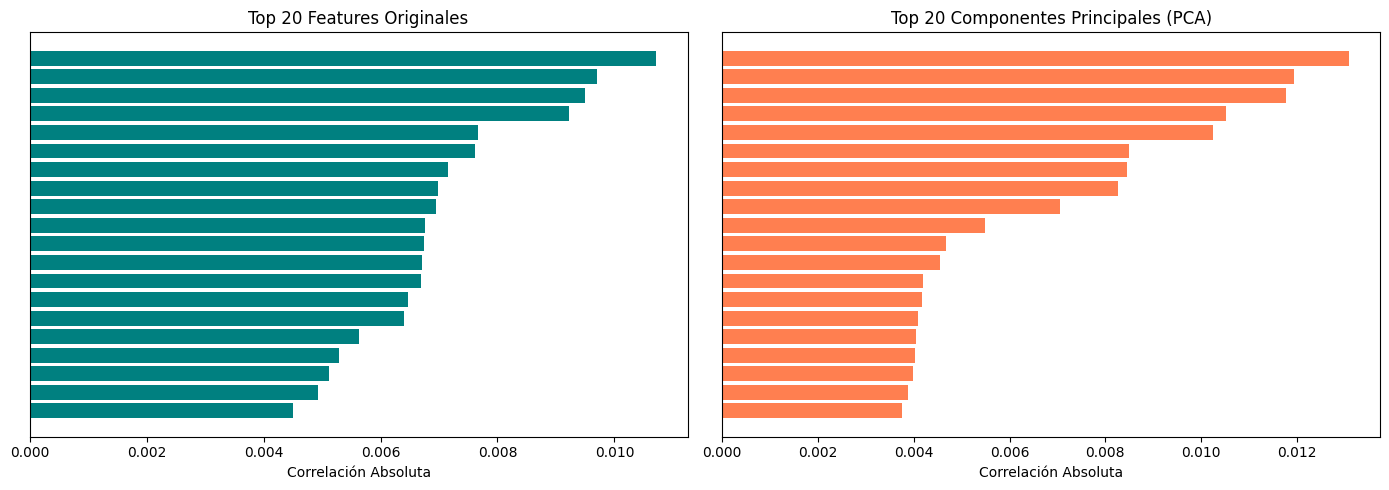

In [18]:
# Recalcular correlaciones para las features originales después del filtrado
current_features_in_train = [col for col in train.columns if col not in ['era', 'target']]
correlations = train[current_features_in_train].corrwith(train['target']).abs().sort_values(ascending=False)


# Calcular correlaciones para los componentes principales
pc_correlations = train_pca[[c for c in train_pca.columns if c.startswith('PC')]].corrwith(train_pca['target']).abs().sort_values(ascending=False)

print(f"\n TOP 10 COMPONENTES PRINCIPALES MÁS CORRELACIONADOS:")
print(pc_correlations.head(10))

# Visualización comparativa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graficar correlaciones de features originales
num_features_to_plot = min(20, len(correlations))
ax1.barh(range(num_features_to_plot), correlations.head(num_features_to_plot).values[::-1], color='teal')
ax1.set_xlabel('Correlación Absoluta')
ax1.set_title(f'Top {num_features_to_plot} Features Originales')
ax1.set_yticks([])


# Graficar correlaciones de componentes principales
num_pcs_to_plot = min(20, len(pc_correlations))
ax2.barh(range(num_pcs_to_plot), pc_correlations.head(num_pcs_to_plot).values[::-1], color='coral')
ax2.set_xlabel('Correlación Absoluta')
ax2.set_title(f'Top {num_pcs_to_plot} Componentes Principales (PCA)')
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('grafica7_comparacion_preprocesamiento.png', bbox_inches='tight')
plt.show()

2.- MODELING

###División del conjunto de datos



> En esta parte divido los datos de forma secuencial por eras para respetar el orden temporal. Utilizo el 80% de las primeras eras para entrenar el modelo, el siguiente 10% para validarlo y el 10% final para probarlo. Después creo los conjuntos de entrenamiento, validación y prueba, separando las variables independientes (las componentes principales del PCA) del objetivo target, lo que deja los datos listos para el entrenamiento del modelo.





In [19]:
# Divide eras secuencialmente.
eras = sorted(train_pca["era"].unique())
total = len(eras)
train_end = int(total * 0.8)
val_end = int(total * 0.9)

train_eras = eras[:train_end]
val_eras = eras[train_end:val_end]
test_eras = eras[val_end:]

# Crea conjuntos.
train = train_pca[train_pca["era"].isin(train_eras)].copy()
val = train_pca[train_pca["era"].isin(val_eras)].copy()
test = train_pca[train_pca["era"].isin(test_eras)].copy()

# Separa características y objetivo.
cols = [c for c in train_pca.columns if c.startswith("PC")]
X_train = train[cols]
y_train = train["target"]
X_val = val[cols]
y_val = val["target"]
X_test = test[cols]
y_test = test["target"]

Hiperparametros

In [21]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}




> Elegí usar el modelo Random Forest porque me pareció el más equilibrado entre precisión, estabilidad y facilidad de interpretación. Funciona bien con datos con ruido y relaciones no lineales, y no necesita tantos ajustes como otros modelos más complejos. Además, es menos propenso al sobreajuste, por lo que decidí descartarlos y quedarme con este por su buen rendimiento y simplicidad.




In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

best_score = float('inf')
best_params = None
best_model = None

for n in param_grid['n_estimators']:
    for d in param_grid['max_depth']:
        model = RandomForestRegressor(
            n_estimators=n,
            max_depth=d,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

        # Validación temporal
        y_pred_val = model.predict(X_val)
        score = mean_squared_error(y_val, y_pred_val)

        if score < best_score:
            best_score = score
            best_params = {'n_estimators': n, 'max_depth': d}
            best_model = model

print("Mejores hiperparámetros:", best_params)
print("Error cuadrático medio (validación):", best_score)


Mejores hiperparámetros: {'n_estimators': 100, 'max_depth': 5}
Error cuadrático medio (validación): 0.04974482594177326



> El overfitting ocurre cuando un modelo aprende demasiado bien los datos de entrenamiento, incluyendo el ruido o detalles irrelevantes, lo que provoca que funcione mal con datos nuevos. Se evita separando correctamente los conjuntos de entrenamiento, validación y prueba, limitando la complejidad del modelo, aplicando técnicas de regularización o reducción de dimensionalidad como PCA como he usado.



In [26]:
# Descarga validation data
# Esto tomará unos pocos minutos 🍵
napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set # Keep using original feature_set for initial load
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]


validation_features = validation[selected_features_corr]
validation_scaled = scaler.transform(validation_features)

validation_pca = pca.transform(validation_scaled)
validation_pca_df = pd.DataFrame(validation_pca, index=validation.index, columns=[f'PC{i+1}' for i in range(validation_pca.shape[1])])

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = best_model.predict(validation_pca_df)
validation[["era", "prediction", "target"]]

,era,prediction,target
id,,,
n000101811a8a843,0575,0.496431,0.75
n001e1318d5072ac,0575,0.501084,0.00
n002a9c5ab785cbb,0575,0.491162,0.50
n002ccf6d0e8c5ad,0575,0.511134,0.00
n0041544c345c91d,0575,0.508418,0.50
...,...,...,...
nffd0c1ab7ff94e1,1187,0.497405,0.25
nffd4bee61d1e1ee,1187,0.495935,0.75
nffdcf95cd4ee09c,1187,0.496122,0.25


Evaluar los resultados usando el coeficiente de correlación de Pearson en este caso lo importante no es clasificar correctamente cada muestra, sino medir la relación entre las predicciones y los valores reales. En problemas como este, de tipo continuo y financiero, lo que interesa es que el modelo mantenga una tendencia similar al objetivo, no que acierte clases específicas. Por eso no tendría sentido usar métricas como F1-score, que se aplican a problemas de clasificación binaria, mientras que la correlación permite evaluar si las predicciones varían en la misma dirección que los valores reales.


In [34]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # Handle empty Series input
    if preds.empty or target.empty:
        return np.nan
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]



>El gráfico muestra la correlación por era entre las predicciones del modelo y los valores reales. Cada barra representa cómo de alineadas estuvieron las predicciones con los resultados durante un periodo concreto. Se puede ver que la mayoría de las correlaciones son positivas, aunque con cierta variabilidad entre eras, lo cual es normal en datos financieros. En general, el modelo mantiene una relación estable con el objetivo, aunque con algunas fluctuaciones que reflejan los cambios en las condiciones del mercado.




/tmp/ipython-input-4115117872.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


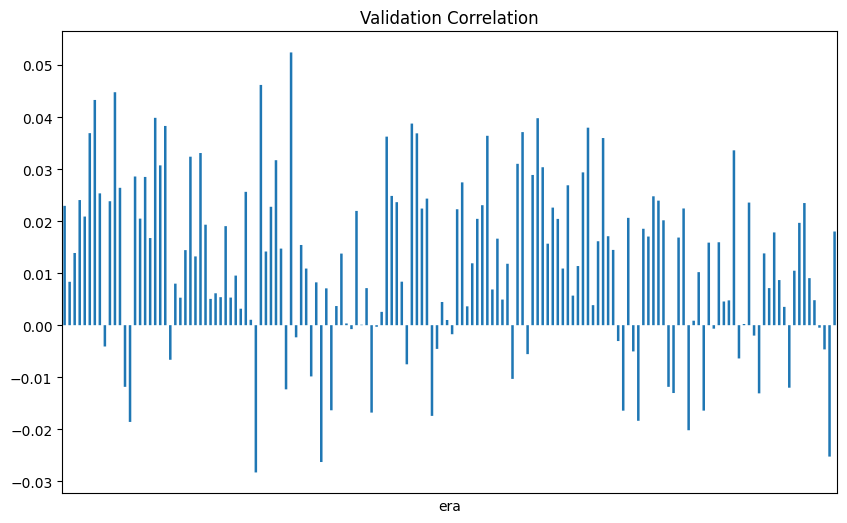

In [28]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era"
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);



> El gráfico muestra la correlación acumulada de validación a lo largo de las eras. Se observa una tendencia ascendente constante, lo que indica que el modelo mantiene un desempeño positivo y estable en el tiempo. Esto significa que, aunque existan pequeñas variaciones entre eras individuales, en conjunto el modelo logra predecir de manera consistente en la misma dirección que los valores reales, reflejando una buena capacidad general de generalización.




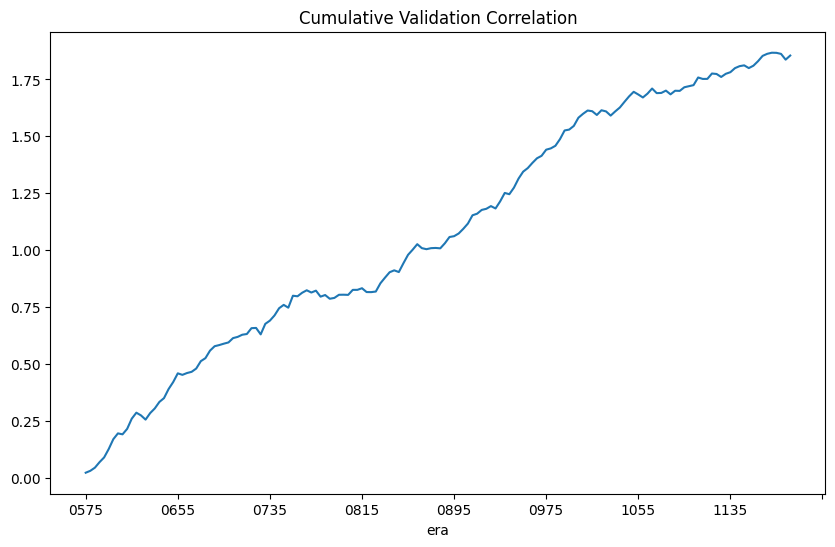

In [29]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));



> Los resultados muestran que el modelo tiene una correlación media de 0.012, lo que indica una relación positiva aunque débil entre las predicciones y los valores reales, algo esperado en datos financieros donde las señales suelen ser pequeñas. La desviación estándar de 0.0165 refleja cierta variabilidad en el desempeño entre eras. El Sharpe de 0.72 indica que esa variabilidad, el modelo mantiene un rendimiento relativamente consistente. Finalmente, el max drawdown de 0.037 muestra que la mayor caída acumulada en la correlación fue moderada, lo que indica que el modelo es estable y no sufre grandes pérdidas de rendimiento en determinados periodos.




In [30]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

,Value
mean,0.012044
std,0.016531
sharpe,0.728586
max_drawdown,0.037197


 Neutralización de predicciones



> En esta parte del código aplico una técnica llamada neutralización, que sirve para eliminar la influencia lineal de ciertas variables (en este caso, las componentes principales del PCA) sobre las predicciones del modelo. Lo que hago es ajustar las predicciones para que no estén correlacionadas con esos factores dominantes, evitando que el modelo dependa demasiado de ellos. Después de neutralizar, vuelvo a calcular la correlación por era entre las nuevas predicciones y el objetivo, comparando el resultado antes y después de aplicar la neutralización para ver si las predicciones se vuelven más robustas y equilibradas.




In [35]:
def neutralize(series, neutralizers, proportion=1.0):
    """
    Elimina de 'series' la influencia lineal de 'neutralizers'.
    """
    scores = series.values
    exposures = neutralizers.values
    exposures = exposures / np.sqrt((exposures ** 2).sum(axis=0, keepdims=True))
    correction = exposures.dot(exposures.T.dot(scores))
    neutralized = scores - proportion * correction
    return pd.Series(neutralized, index=series.index)

# Neutraliza las predicciones respecto a las PCs
validation["neutralized_prediction"] = neutralize(validation["prediction"], validation_pca_df)

# Calcular correlacion por era
corr_after_neutral_per_era = validation.groupby("era").apply(
    lambda x: practica_corr(x["neutralized_prediction"], x["target"])
)

validation["corr_after_neutral"] = validation["era"].map(corr_after_neutral_per_era)


print("\nCorrelación promedio antes de neutralizar:", per_era_corr.mean())
print("Correlación promedio después de neutralizar:",
      validation["corr_after_neutral"].mean())


Correlación promedio antes de neutralizar: 0.012044122239424675
Correlación promedio después de neutralizar: 0.0035714938844267326


/tmp/ipython-input-879166821.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_after_neutral_per_era = validation.groupby("era").apply(


SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [37]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

live_features_filtered = live_features[selected_features_corr]
live_scaled = scaler.transform(live_features_filtered)
live_pca = pca.transform(live_scaled)


live_pca_df = pd.DataFrame(live_pca, index=live_features.index, columns=[f'PC{i+1}' for i in range(live_pca.shape[1])])


# Genera predicciones en vivo
live_predictions = best_model.predict(live_pca_df)



# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction").head()

,prediction
id,
n0022ea68a1e38fc,0.505657
n0035a68ec0cb755,0.505077
n0038a969a400336,0.500260
n003a6a571877c7c,0.502652
n003c6e8f8fd0984,0.496796


#cloudpickle



> En este bloque guardo todo mi modelo entrenado y su proceso de preprocesamiento en un solo archivo para poder reutilizarlo después sin tener que volver a entrenarlo. Uso la librería **cloudpickle** para serializar tanto el modelo, como el escalador, el PCA y la función de predicción que aplica todo el pipeline. De esta forma, el artefacto **`modelo_final.pkl`** contiene todo lo necesario para cargarlo y generar nuevas predicciones fácilmente en otro entorno o momento.



In [38]:
import cloudpickle

def modelo_final_predictor(data, scaler, pca, model):
    # Escalar los datos
    data_scaled = scaler.transform(data)
    # Aplicar PCA
    data_pca = pca.transform(data_scaled)
    # Hacer predicciones
    preds = model.predict(data_pca)
    return preds

# diccionario con todos los componentes importantes
artifact = {
    "scaler": scaler,                # Estandarizador ajustado
    "pca": pca,                      # PCA ajustado
    "model": best_model,             # Modelo entrenado (Random Forest)
    "predict_func": modelo_final_predictor,  # Función para predecir
    "features": feature_cols_pca,    # Lista de columnas originales usadas
}

# Guardar el artefacto en disco
with open("modelo_final.pkl", "wb") as f:
    cloudpickle.dump(artifact, f)

print("✅ Artefacto guardado como 'modelo_final.pkl'")


✅ Artefacto guardado como 'modelo_final.pkl'
